# Plot raw detector frames

Inspect raw detector images, no integration. Useful for:

- Quickly checking raw image files before further analysis.
- Spotting saturated pixels, beamstop shadows, weird artefacts.

In [6]:
import matplotlib.pyplot as plt

from giwaxs_analysis import calibration, io, plotting, integration

## 1. (Optional) Load a calibration

Loading a `Calibration` gives `plot_detector` access to the mask, so masked pixels (dead pixels, module gaps, beamstop shadow) are rendered transparent instead of skewing the colour scale.

You can skip this cell entirely and pass `calib=None` below — you'll just see the raw data with the masked regions still visible. **If you haven't done the calibration yet, skip this step**.

In [11]:
PONI_PATH = '../data/calibrant_AgBh.poni'
MASK_PATH = '../data/mask.edf'

calib = calibration.load_calibration(PONI_PATH, MASK_PATH)

## 2. Plot a single frame

Log scale and viridis colormap by default; tweak `VMIN`/`VMAX` to bring out faint features or saturate bright ones.

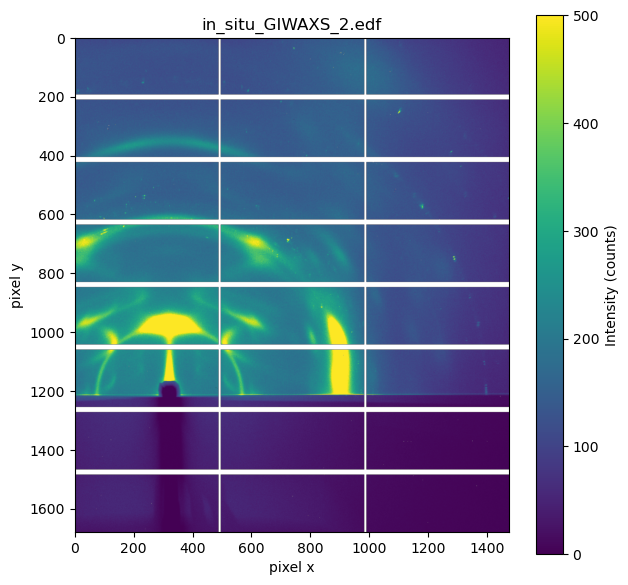

In [17]:
SAMPLE_PATH = '../data/insitu/in_situ_GIWAXS_2.edf'

VMIN = None     # e.g. 10 to suppress noise
VMAX = 500     # e.g. 5000 to saturate bright pixels and bring out weak features
LOG_SCALE = False  # False for linear colour scale

frame = io.load_frame(SAMPLE_PATH)
fig, ax = plotting.plot_detector(
    frame,
    calib=calib,
    log=LOG_SCALE, 
    vmin=VMIN,
    vmax=VMAX,
    title=SAMPLE_PATH.rsplit('/', 1)[-1],
)
plt.show()

## 3. Plot every frame in a folder

`list_frames` + `load_stack` pull every detector file in a folder into a single 3D array, then `plot_detector_grid` draws them all sharing the same colour scale (so frame-to-frame intensity differences are real).

Found 5 frames in ../data/insitu/


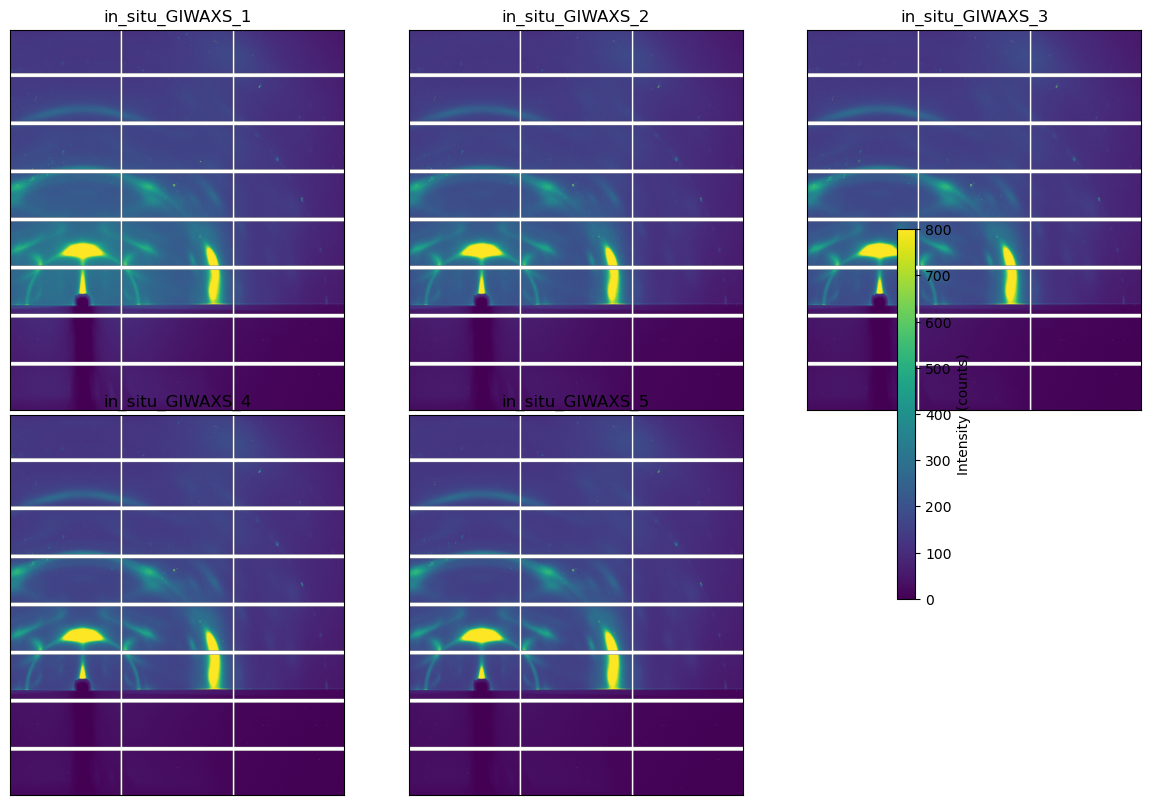

In [22]:
FOLDER = '../data/insitu/'

VMIN = None     # e.g. 10 to suppress noise
VMAX = 800   # e.g. 5000 to saturate bright pixels and bring out weak features
LOG_SCALE = False  # False for linear colour scale

paths = io.list_frames(FOLDER)
print(f'Found {len(paths)} frames in {FOLDER}')

stack = io.load_stack(paths)
labels = [p.stem for p in paths]

fig, axes = plotting.plot_detector_grid(
    stack,
    calib=calib,
    labels=labels,
    ncols=3,
    log=LOG_SCALE,
    vmin=VMIN,
    vmax=VMAX,
)
plt.show()

## A note on file formats

`io.list_frames` defaults to matching `*.edf` (ESRF / ALS convention). For Diamond data (TIFF), pass an explicit pattern:

```python
io.list_frames(FOLDER, pattern='*.tif')
```

## 4. Cake a real sample

Real samples are messier than the calibrant but the rules are the same. Reading off the cake tells you:

- Which q-rings are present (peaks at certain q values).
- How their intensity varies with χ (preferred orientation / texture).

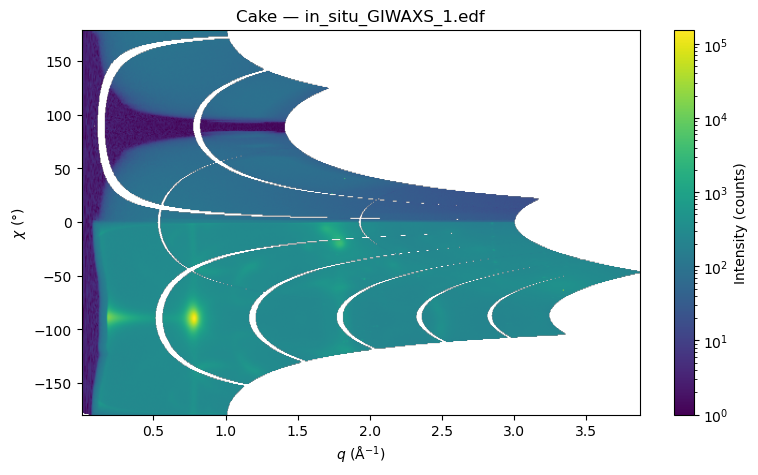

In [10]:

sample_frame = io.load_frame(SAMPLE_PATH)
q_s, chi_s, I_s = integration.cake(sample_frame, calib, npt_rad=1000, npt_azim=360)

fig, ax = plotting.plot_cake(
    q_s, chi_s, I_s,
    title=f'Cake — {SAMPLE_PATH.rsplit("/", 1)[-1]}',
)
plt.show()